# asymptotics — Coupled ODE Systems

`ODESystem` applies regular perturbation to **coupled systems of ODEs**.

## The key insight

For a system like:
$$u' + u + \varepsilon v = 0, \qquad v' + 2v + \varepsilon u^2 = 0$$

At each order $k$, the equations for $u_k(t)$ and $v_k(t)$ are **decoupled** — each depends only on lower-order solutions. So we solve $N$ independent ODEs at every order, one per variable.

The interface is identical to `ODE` — just provide multiple equations and dependents:

```python
from asymptotics import ODESystem

sys = ODESystem(
    equations   = ["u' + u + eps*v", "v' + 2*v + eps*u**2"],
    dependents  = ["u", "v"],
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "v(0) = 1"],
)
sol = sys.expand_regular(order=2)
sol.show()
```

In [1]:
from asymptotics import ODESystem

---
## Example 1 — Weakly coupled decay equations

$$u' + u + \varepsilon v = 0, \qquad u(0) = 1$$
$$v' + 2v + \varepsilon u^2 = 0, \qquad v(0) = 1$$

At $\mathcal{O}(1)$: decoupled exponential decays $u_0 = e^{-t}$, $v_0 = e^{-2t}$.

At $\mathcal{O}(\varepsilon)$: coupling enters — $v_0$ drives $u_1$, and $u_0^2$ drives $v_1$.

In [2]:
sys1 = ODESystem(
    equations   = ["u' + u + eps*v", "v' + 2*v + eps*u**2"],
    dependents  = ["u", "v"],
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "v(0) = 1"])
sol1 = sys1.expand_regular(order=2)
sol1.show()

  ℹ️  independent = 't' (supplied)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

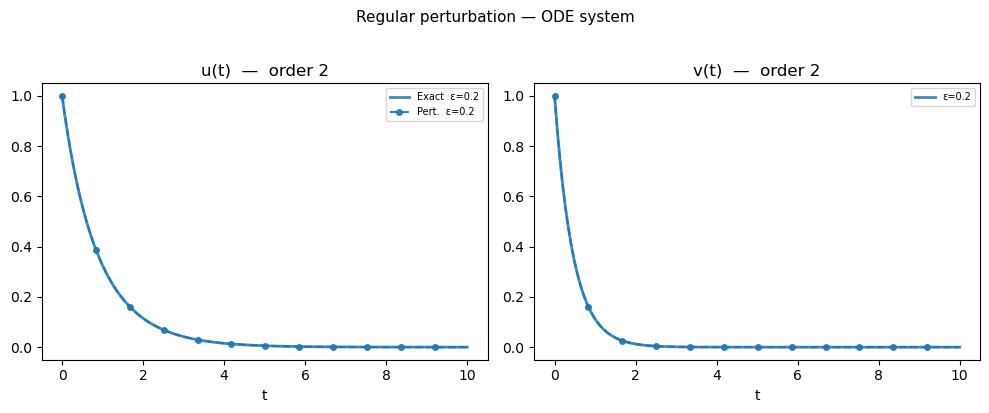

In [4]:
eps_val = 0.2
result  = sol1.compare_numeric(eps=eps_val, t_range=[0, 6])

---
## Example 2 — Cross-coupling: u drives v, v drives u

$$u' + u + \varepsilon v^2 = 0, \qquad u(0) = 1$$
$$v' + 2v + \varepsilon u = 0, \qquad v(0) = 0$$

With $v(0) = 0$, the O(1) solution $v_0 = 0$ means $u$ is unaffected at O(ε) (since $v_0^2 = 0$). The first non-trivial coupling appears at O(ε²).

In [5]:
sys2 = ODESystem(
    equations   = ["u' + u + eps*v**2", "v' + 2*v + eps*u**2"],
    dependents  = ["u", "v"],
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 0.1", "v(0) = 0"])
sol2 = sys2.expand_regular(order=2)
sol2.show()

  ℹ️  independent = 't' (supplied)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

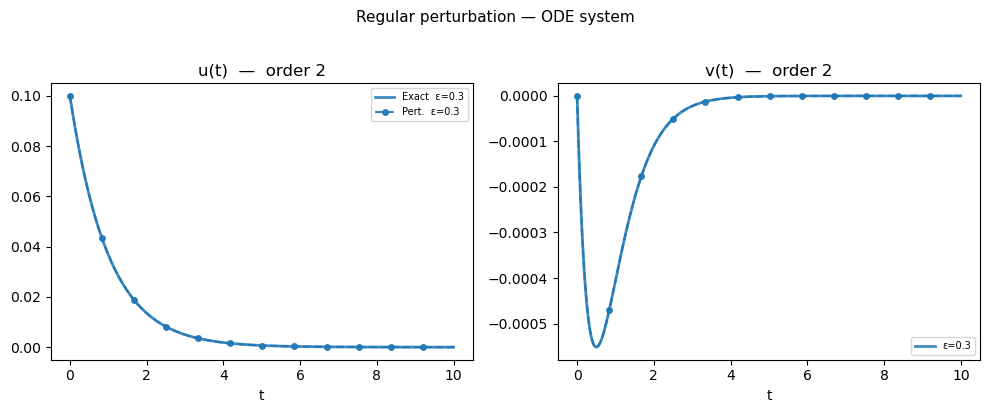

In [6]:
eps_val = 0.3
result  = sol2.compare_numeric(eps=eps_val, t_range=[0, 6])

---
## Example 3 — Three-equation cascade

$$u' + u + \varepsilon v = 0, \qquad u(0) = 1$$
$$v' + 2v + \varepsilon u^2 = 0, \qquad v(0) = 1$$
$$w' + w + \varepsilon(u + v) = 0, \qquad w(0) = 0$$

The third variable $w$ is driven by both $u$ and $v$. At O(1): $w_0 = 0$. At O(ε): $w$ picks up contributions from $u_0$ and $v_0$.

In [2]:
sys3 = ODESystem(
    equations   = ["u' + u + eps*v", "v' + 2*v + eps*u**2", "w' + w + eps*(u+v)"],
    dependents  = ["u", "v", "w"],
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "v(0) = 1", "w(0) = 0"])
sol3 = sys3.expand_regular(order=2)
sol3.show()

  ℹ️  independent = 't' (supplied)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

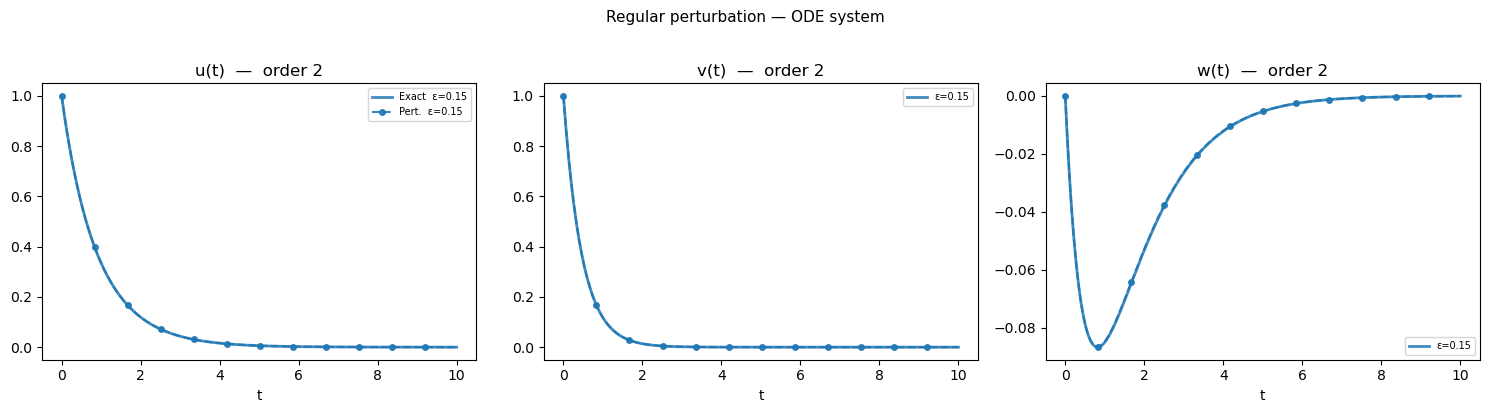

In [4]:
eps_val = 0.15
result  = sol3.compare_numeric(eps=eps_val, t_range=[0, 6])

---
## Example 4 — Predator-prey (Lotka-Volterra type)

$$u' - u + \varepsilon u v = 0, \qquad u(0) = 1$$
$$v' + 2v - \varepsilon u v = 0, \qquad v(0) = 1$$

At O(1): $u_0 = e^{t}$ (prey grows), $v_0 = e^{-2t}$ (predators decay without prey).

The coupling $\varepsilon uv$ at O(ε) captures the predator-prey interaction. This system is valid for small t.

In [19]:
sys4 = ODESystem(
    equations   = ["u' - u + eps*u*v", "v' + 2*v - eps*u*v"],
    dependents  = ["u", "v"],
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "v(0) = 1"])
sol4 = sys4.expand_regular(order=1)
sol4.show()

  ℹ️  independent = 't' (supplied)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

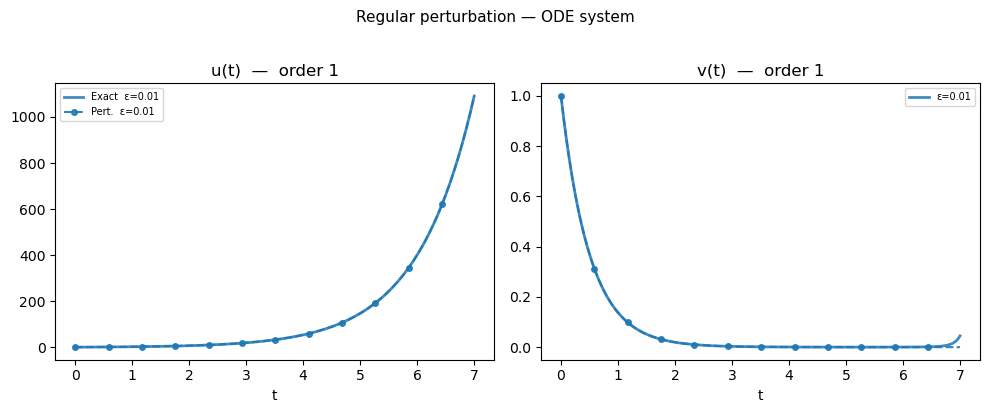

In [20]:
eps_val = 0.01
result  = sol4.compare_numeric(eps=eps_val, plot_range=[0, 7])

---
## API quick reference

```python
from asymptotics import ODESystem

sys = ODESystem(
    equations   = ["u' + u + eps*v", "v' + 2*v + eps*u**2"],
    dependents  = ["u", "v"],          # one per equation
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "v(0) = 1"],  # flat list, auto-matched
)

sol = sys.expand_regular(order=2)

# Display
sol.show()                          # full hierarchy (LaTeX in Jupyter)

# Access by variable name
sol["u"].expansion                  # full expansion for u
sol["v"].expansion                  # full expansion for v
sol["u"][k].particular_solution    # u_k(t) at order k
sol["v"][k].ode                    # ODE for v_k at order k

# Works for N equations
sys3 = ODESystem(
    equations  = ["u' + u + eps*v", "v' + 2*v + eps*u**2", "w' + w + eps*(u+v)"],
    dependents = ["u", "v", "w"],
    ...
)
```

**Condition syntax** — same as `ODE`, flat list auto-matched by variable name:
```python
conditions = ["u(0) = 1", "v(0) = 0"]          # 1st-order system
conditions = ["u(0) = 1", "u'(0) = 0",          # 2nd-order u
              "v(0) = 0"]                        # 1st-order v
```